all imports working


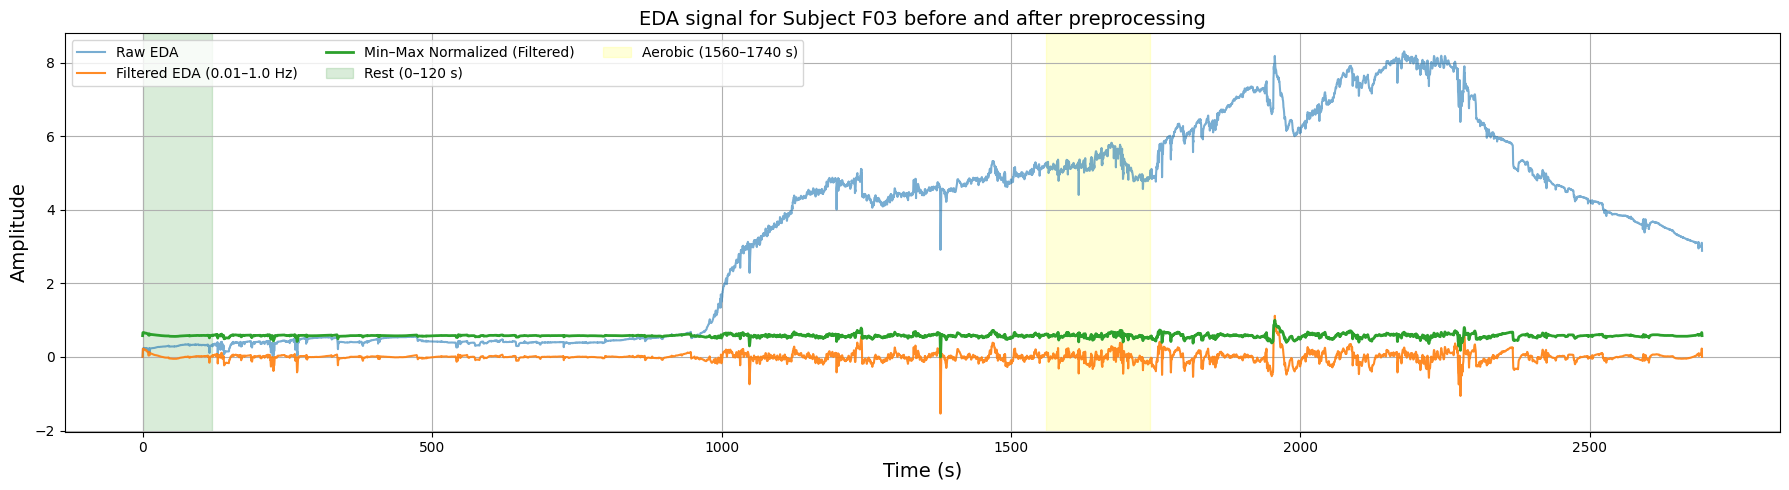

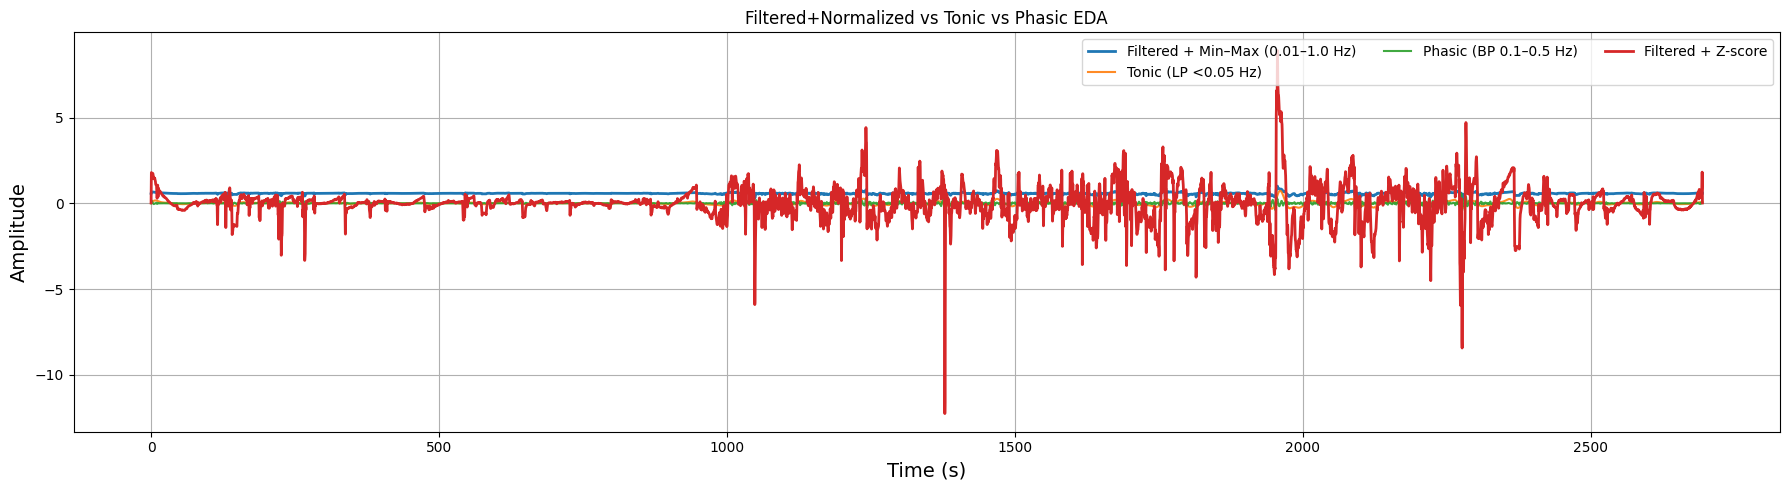

C:\Users\Ramya Sankar\AppData\Local\Temp\ipykernel_43188\3588025511.py:118: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(-0, 1.0)          # <-- add this


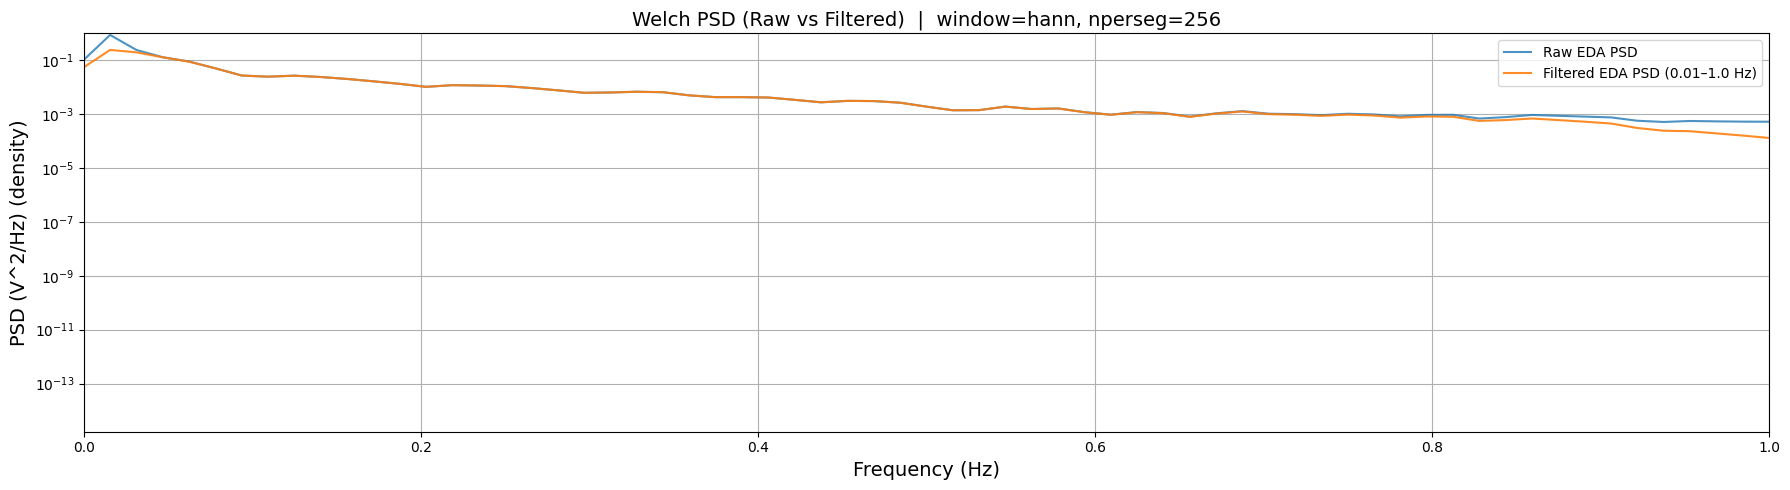

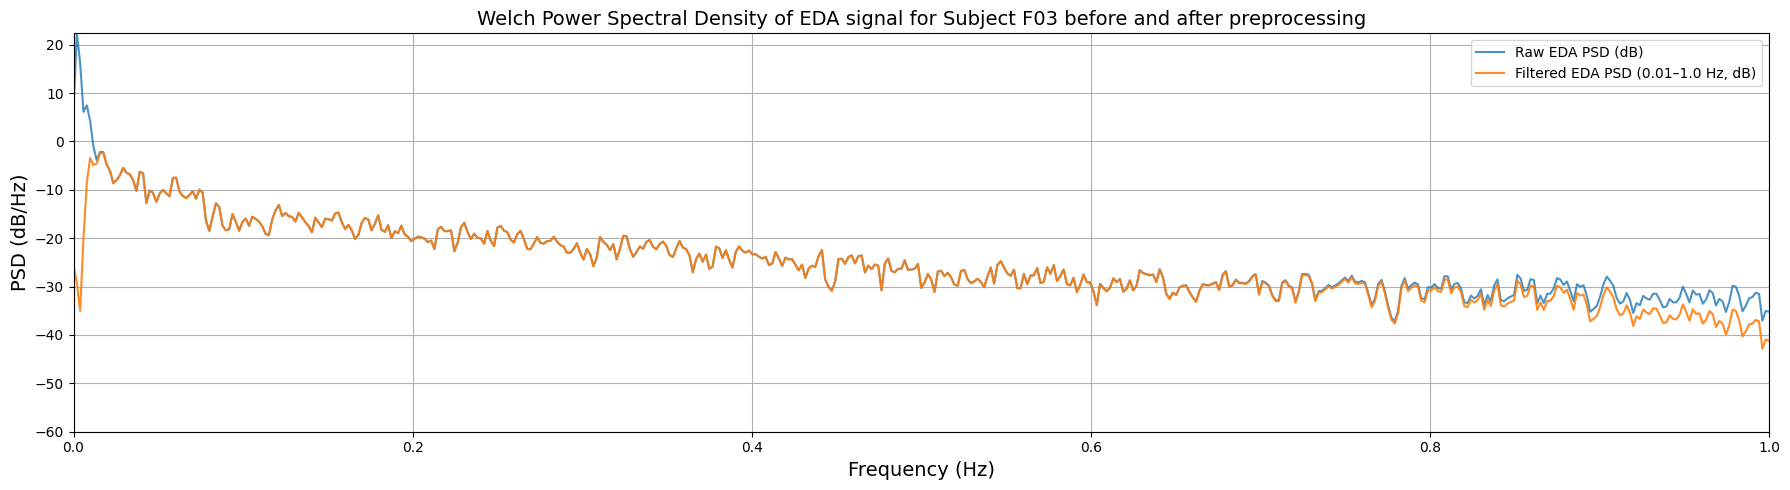

In [25]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt
from biosppy import storage
from scipy.signal import butter, filtfilt, welch  # <-- added welch

print("all imports working")

def butter_bandpass(x, fs, low_hz, high_hz, order=4):
    x = np.asarray(x, dtype=float)
    nyq = 0.5 * fs
    b, a = butter(order, [low_hz / nyq, high_hz / nyq], btype="band")
    return filtfilt(b, a, x)

def butter_lowpass(x, fs, cutoff_hz, order=4):
    x = np.asarray(x, dtype=float)
    nyq = 0.5 * fs
    b, a = butter(order, cutoff_hz / nyq, btype="low")
    return filtfilt(b, a, x)

def minmax_normalize(x):
    x = np.asarray(x, dtype=float)
    mn, mx = np.min(x), np.max(x)
    if mx - mn < 1e-12:
        return np.zeros_like(x)
    return (x - mn) / (mx - mn)

def zscore_normalize(x, eps=1e-12):
    x = np.asarray(x, dtype=float)
    mu = np.mean(x)
    sigma = np.std(x)
    if sigma < eps:
        return np.zeros_like(x)
    return (x - mu) / sigma

def choose_nperseg(n, fs, target_seconds=64):
    """
    Welch needs nperseg <= len(x). For EDA @ 4Hz, 64s => 256 samples (nice default).
    """
    nperseg = int(round(target_seconds * fs))
    nperseg = max(16, nperseg)   # avoid tiny segments
    nperseg = min(nperseg, n)    # must be <= length
    return nperseg

def main():
    #fname = r"C:\Users\Ramya Sankar\Downloads\EDA_Files\Wearable_Dataset\STRESS\F02.txt" #STRESS
    fname = r"C:\Users\Ramya Sankar\Downloads\EDA_Files\Wearable_Dataset\AEROBIC\F03.txt" #AEROBIC
    #fname = r"C:\Users\Ramya Sankar\Downloads\EDA_Files\Wearable_Dataset\ANAEROBIC\S08.txt" #ANEROBIC

    signal, meta = storage.load_txt(fname)
    fs = 4.0
    if isinstance(meta, dict):
        fs = float(meta.get("sampling_rate", meta.get("sr", fs)))

    raw_eda = np.asarray(signal, dtype=float)
    t = np.arange(len(raw_eda)) / fs

    # Preprocess bandpass (0.01–1.0 Hz)
    filtered_eda = butter_bandpass(raw_eda, fs, low_hz=0.01, high_hz=1.0, order=4)
    filtered_minmax = minmax_normalize(filtered_eda)

    filtered_zscore = zscore_normalize(filtered_eda) #z-core normalization - comment out if using only MIN MAX

    # Tonic / Phasic from the filtered signal
    tonic_eda = butter_lowpass(filtered_eda, fs, cutoff_hz=0.05, order=4)             # <0.05 Hz
    phasic_eda = butter_bandpass(filtered_eda, fs, low_hz=0.1, high_hz=0.5, order=4)  # 0.1–0.5 Hz

    # -------- Chart 1: Raw vs Filtered vs Min-Max --------
    plt.figure(figsize=(18, 5))
    plt.plot(t, raw_eda, label="Raw EDA", alpha=0.6)
    plt.plot(t, filtered_eda, label="Filtered EDA (0.01–1.0 Hz)", alpha=0.9)
    plt.plot(t, filtered_minmax, label="Min–Max Normalized (Filtered)", linewidth=2)
    #plt.plot(t, filtered_zscore, label="Z-score Normalized (Filtered)", linewidth=2) #z-score comment out if using only MIN MAX
    plt.title("EDA signal for Subject F03 before and after preprocessing", fontsize=14)
    plt.xlabel("Time (s)", fontsize=14)
    plt.ylabel("Amplitude", fontsize=14)
    # Rest period
    plt.axvspan(0, 120, color="green", alpha=0.15, label="Rest (0–120 s)")  
    # Aerobic period
    plt.axvspan(1560, 1740, color="yellow", alpha=0.15, label="Aerobic (1560–1740 s)")
    plt.grid(True)
    plt.legend(ncol=3, loc="upper left")
    plt.tight_layout()
    plt.show()

    # -------- Chart 2: Filtered+Normalized vs Tonic vs Phasic --------
    plt.figure(figsize=(18, 5))
    plt.plot(t, filtered_minmax, label="Filtered + Min–Max (0.01–1.0 Hz)", linewidth=2)
    plt.plot(t, tonic_eda, label="Tonic (LP <0.05 Hz)", alpha=0.9)
    plt.plot(t, phasic_eda, label="Phasic (BP 0.1–0.5 Hz)", alpha=0.9)
    plt.plot(t, filtered_zscore, label="Filtered + Z-score", linewidth=2) #z-score comment out if using only MIN MAX
    plt.title("Filtered+Normalized vs Tonic vs Phasic EDA")
    plt.xlabel("Time (s)", fontsize=14)
    plt.ylabel("Amplitude", fontsize=14)
    plt.grid(True)
    plt.legend(ncol=3, loc="upper right")
    plt.tight_layout()
    plt.show()

    # =========================
    # Welch PSD (added charts)
    # =========================
    nperseg = choose_nperseg(len(raw_eda), fs, target_seconds=64)

    freqs_raw, psd_raw = welch(raw_eda, fs=fs, window="hann", nperseg=nperseg, scaling="density")
    freqs_filt, psd_filt = welch(filtered_eda, fs=fs, window="hann", nperseg=nperseg, scaling="density")
    freqs_tonic, psd_tonic = welch(tonic_eda, fs=fs, window="hann", nperseg=nperseg, scaling="density")
    freqs_phasic, psd_phasic = welch(phasic_eda, fs=fs, window="hann", nperseg=nperseg, scaling="density")

    # -------- Chart 3: Welch PSD (Raw vs Filtered) --------
    plt.figure(figsize=(18, 5))
    plt.semilogy(freqs_raw, psd_raw, label="Raw EDA PSD", alpha=0.8)
    plt.semilogy(freqs_filt, psd_filt, label="Filtered EDA PSD (0.01–1.0 Hz)", alpha=0.9)
    plt.title(f"Welch PSD (Raw vs Filtered)  |  window=hann, nperseg={nperseg}", fontsize=14)
    plt.xlabel("Frequency (Hz)", fontsize=14)
    plt.ylabel("PSD (V^2/Hz) (density)", fontsize=14)
    plt.xlim(0, 1.0)          # <-- add this
    plt.ylim(-0, 1.0)          # <-- add this
    plt.grid(True)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    # ---- Welch PSD: clean, interpretable ----
    nperseg = min(2048, len(raw_eda))  # 2048 samples = 512 sec at 4 Hz #nperseg = 256

    freqs_raw, psd_raw = welch(
        raw_eda - np.mean(raw_eda),
        fs=fs,
        window="hann",
        nperseg=nperseg,
        scaling="density"
    )

    freqs_filt, psd_filt = welch(
        filtered_eda - np.mean(filtered_eda),
        fs=fs,
        window="hann",
        nperseg=nperseg,
        scaling="density"
    )

    # Convert to dB so peaks are visible
    psd_raw_db  = 10 * np.log10(psd_raw + 1e-20)
    psd_filt_db = 10 * np.log10(psd_filt + 1e-20)

    plt.figure(figsize=(18, 5))
    plt.plot(freqs_raw, psd_raw_db, label="Raw EDA PSD (dB)", alpha=0.8) 
    plt.plot(freqs_filt, psd_filt_db, label="Filtered EDA PSD (0.01–1.0 Hz, dB)", alpha=0.9)

    plt.title("Welch Power Spectral Density of EDA signal for Subject F03 before and after preprocessing", fontsize=14)
    plt.xlabel("Frequency (Hz)", fontsize=14)
    plt.ylabel("PSD (dB/Hz)", fontsize=14)
    #plt.axvspan(0.01, 0.05, alpha=0.1, label="Tonic band")
    #plt.axvspan(0.1, 0.5, alpha=0.1, label="Phasic band")
    plt.xlim(0, 1.0)

    # tighten y-range so structure is visible
    ymin = max(min(psd_raw_db.min(), psd_filt_db.min()), -60)
    ymax = max(psd_raw_db.max(), psd_filt_db.max())
    plt.ylim(ymin, ymax)
    plt.grid(True)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()
if __name__ == "__main__":
    main()